# 🚗 Comparaison Produits Auto — Produit A vs Produit V

**Objectif :** Analyser et comparer deux portefeuilles d'assurance automobile aux structures hétérogènes.  
Les deux datasets n'ont pas les mêmes variables ni les mêmes modalités — on construit un mapping  
d'harmonisation avant toute analyse.

---

| | **Produit A** | **Produit V** |
|---|---|---|
| Taille | 18 000 contrats | 14 000 contrats |
| Âge conducteur | Tranches (`18-25`, `26-35`, …) | Valeur brute (entier) |
| Carburant | `Essence`, `Diesel`, `Hybride`, `GPL`, `Electrique` | Codes courts `E`, `D`, `HY`, `EL`, `GN`, `AU` |
| Garantie | `RC`, `DOMMAGES`, `VOL`, `BRIS_GLACE`, `ASSISTANCE` | `RCO`, `DOM`, `VL`, `BG`, `ASS`, `PJ` |
| Usage | `Promenade`, `Tous Trajets`, `Professionnel`, `Tournées` | `Perso`, `Mixte`, `Pro`, `Loisir`, `Service` |
| Géographie | Région (6 modalités) | Numéro de département |

---

**Plan du notebook**
1. Imports & configuration
2. Génération des datasets synthétiques
3. Mapping & harmonisation des variables
4. KPIs globaux
5. KPIs par garantie
6. Analyse univariée — Âge
7. Analyse univariée — Carburant
8. Analyse univariée — Usage & Ancienneté permis
9. Analyse bivariée
10. Synthèse comparative


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

# ─── Palette & style ────────────────────────────────────────────
BG      = "#0F1117"
PANEL   = "#1A1D27"
BORDER  = "#2E3147"
GRID    = "#252836"
TEXT    = "#E8EAF0"
MUTED   = "#7B7F99"
ACCENT  = "#FFE66D"

A_MAIN  = "#FF6B6B"   # coral  → Produit A
A_LIGHT = "#FF9F9F"
V_MAIN  = "#4ECDC4"   # teal   → Produit V
V_LIGHT = "#A8E6E2"

CARB_COLORS = {
    "Essence":            "#FF8C42",
    "Diesel":             "#6C8EBF",
    "Hybride/Electrique": "#2ECC71",
    "Autres":             "#95A5A6",
}

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL,
    "axes.edgecolor":     BORDER,
    "axes.labelcolor":    TEXT,
    "axes.titlecolor":    TEXT,
    "axes.titlesize":     11,
    "axes.titleweight":   "bold",
    "axes.labelsize":     9,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "grid.color":         GRID,
    "grid.linewidth":     0.6,
    "xtick.color":        MUTED,
    "ytick.color":        MUTED,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "text.color":         TEXT,
    "legend.fontsize":    8,
    "legend.facecolor":   PANEL,
    "legend.edgecolor":   BORDER,
    "legend.labelcolor":  TEXT,
    "figure.dpi":         120,
})

# ─── Ordres canoniques ──────────────────────────────────────────
AGE_ORDER   = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
CARB_ORDER  = ["Essence", "Diesel", "Hybride/Electrique", "Autres"]
USAGE_ORDER = ["Personnel/Loisir", "Mixte", "Professionnel"]
GAR_ORDER   = ["RC", "Dommages", "Vol", "Bris de Glace", "Assistance", "Protection Juridique"]

print("✓ Configuration OK")


✓ Configuration OK


## 2. Génération des Datasets Synthétiques

Les deux datasets **intentionnellement hétérogènes** reproduisent les différences structurelles  
typiques que l'on rencontre en pratique entre deux produits d'un même portefeuille.


In [2]:
def make_dataset_A(n: int = 18_000) -> pd.DataFrame:
    """
    Produit A — assurance auto standard.

    Particularités :
    - age_tranche : déjà encodé en tranches (str)
    - carburant   : libellés longs (Essence, Diesel, Hybride, GPL, Electrique)
    - garantie    : codes internes (RC, DOMMAGES, VOL, BRIS_GLACE, ASSISTANCE)
    - region      : 6 grandes régions
    """
    garantie = np.random.choice(
        ["RC", "DOMMAGES", "VOL", "BRIS_GLACE", "ASSISTANCE"],
        n, p=[0.30, 0.28, 0.15, 0.17, 0.10]
    )
    carburant = np.random.choice(
        ["Essence", "Diesel", "Hybride", "GPL", "Electrique"],
        n, p=[0.38, 0.35, 0.14, 0.06, 0.07]
    )
    age_tranche = np.random.choice(
        ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"],
        n, p=[0.10, 0.22, 0.25, 0.22, 0.14, 0.07]
    )
    usage = np.random.choice(
        ["Promenade", "Tous Trajets", "Professionnel", "Tournées"],
        n, p=[0.40, 0.35, 0.18, 0.07]
    )
    region = np.random.choice(
        ["IDF", "Sud-Est", "Ouest", "Nord", "Est", "Sud-Ouest"],
        n, p=[0.28, 0.18, 0.15, 0.16, 0.13, 0.10]
    )
    anciennete   = np.clip(np.random.gamma(4, 5, n).astype(int), 0, 45)
    puissance_fis = np.random.choice(
        range(4, 16), n,
        p=[0.04, 0.10, 0.17, 0.22, 0.17, 0.12, 0.07, 0.04, 0.03, 0.02, 0.01, 0.01]
    )

    # ── Primes ──────────────────────────────────────────────────
    prime_base = {"RC": 280, "DOMMAGES": 450, "VOL": 180, "BRIS_GLACE": 90, "ASSISTANCE": 60}
    prime = np.array([prime_base[g] for g in garantie])
    mult_young = np.where(age_tranche == "18-25", 1.35, 1.0)
    mult_carb  = np.where(carburant == "Electrique", 0.88,
                 np.where(carburant == "Hybride", 0.92, 1.0))
    prime_acquise = np.clip(
        prime * np.random.normal(1, 0.15, n) * mult_young * mult_carb, 30, 2500
    ).round(2)

    # ── Sinistres ────────────────────────────────────────────────
    freq_base = {"RC": 0.060, "DOMMAGES": 0.090, "VOL": 0.040,
                 "BRIS_GLACE": 0.100, "ASSISTANCE": 0.150}
    freq = np.array([freq_base[g] for g in garantie])
    freq *= np.where(age_tranche == "18-25", 1.4, 1.0)
    nb_sinistres = np.random.poisson(freq)

    sev_base = {"RC": 4500, "DOMMAGES": 6800, "VOL": 8200,
                "BRIS_GLACE": 320, "ASSISTANCE": 180}
    charge = np.where(
        nb_sinistres > 0,
        [np.random.gamma(2, sev_base[g] / 2) * max(nb_sinistres[i], 1)
         for i, g in enumerate(garantie)],
        0
    ).round(2)

    return pd.DataFrame({
        "police_id":          [f"A{i:06d}" for i in range(n)],
        "garantie":           garantie,
        "age_tranche":        age_tranche,
        "carburant":          carburant,
        "usage":              usage,
        "region":             region,
        "anciennete_permis":  anciennete,
        "puissance_fiscale":  puissance_fis,
        "prime_acquise":      prime_acquise,
        "nb_sinistres":       nb_sinistres,
        "charge_sinistre":    charge,
    })


def make_dataset_V(n: int = 14_000) -> pd.DataFrame:
    """
    Produit V — assurance auto concurrentielle.

    Particularités :
    - age_conducteur : valeur brute (int 18-80), PAS de tranches
    - energie        : codes courts (E, D, HY, EL, GN, AU)
    - couverture     : codes produit internes (RCO, DOM, VL, BG, ASS, PJ)
    - utilisation    : libellés différents (Perso, Mixte, Pro, …)
    - departement    : numéro (int), pas de région
    """
    couverture = np.random.choice(
        ["RCO", "DOM", "VL", "BG", "ASS", "PJ"],
        n, p=[0.28, 0.26, 0.14, 0.16, 0.09, 0.07]
    )
    energie = np.random.choice(
        ["E", "D", "HY", "EL", "GN", "AU"],
        n, p=[0.34, 0.30, 0.16, 0.10, 0.04, 0.06]
    )
    age_conducteur = np.clip(
        np.round(np.random.beta(3, 2.5, n) * 55 + 18).astype(int), 18, 80
    )
    utilisation = np.random.choice(
        ["Perso", "Mixte", "Pro", "Loisir", "Service"],
        n, p=[0.38, 0.28, 0.20, 0.08, 0.06]
    )
    departement  = np.random.randint(1, 96, n)
    annees_permis = np.clip(age_conducteur - 18 - np.random.randint(0, 3, n), 0, 60)
    puissance_din = np.random.choice(range(50, 260, 5), n)

    # ── Primes ──────────────────────────────────────────────────
    prime_base = {"RCO": 260, "DOM": 420, "VL": 190, "BG": 95, "ASS": 55, "PJ": 45}
    prime = np.array([prime_base[g] for g in couverture])
    mult_young = np.where(age_conducteur < 26, 1.30, 1.0)
    mult_el    = np.where(energie == "EL", 0.85, 1.0)
    cotisation = np.clip(
        prime * np.random.normal(1, 0.13, n) * mult_young * mult_el, 25, 2200
    ).round(2)

    # ── Sinistres ────────────────────────────────────────────────
    freq_base = {"RCO": 0.055, "DOM": 0.085, "VL": 0.042,
                 "BG":  0.095, "ASS": 0.140, "PJ": 0.070}
    freq = np.array([freq_base[g] for g in couverture])
    freq *= np.where(age_conducteur < 26, 1.35, 1.0)
    nb_sinistres = np.random.poisson(freq)

    sev_base = {"RCO": 4800, "DOM": 7100, "VL": 8500,
                "BG": 300,  "ASS": 170,  "PJ": 650}
    charge = np.where(
        nb_sinistres > 0,
        [np.random.gamma(2, sev_base[g] / 2) * max(nb_sinistres[i], 1)
         for i, g in enumerate(couverture)],
        0
    ).round(2)

    return pd.DataFrame({
        "contrat_id":       [f"V{i:06d}" for i in range(n)],
        "couverture":       couverture,
        "age_conducteur":   age_conducteur,
        "energie":          energie,
        "utilisation":      utilisation,
        "departement":      departement,
        "annees_permis":    annees_permis,
        "puissance_din":    puissance_din,
        "cotisation":       cotisation,
        "nb_sinistres":     nb_sinistres,
        "charge_sinistre":  charge,
    })


df_A = make_dataset_A(18_000)
df_V = make_dataset_V(14_000)

print(f"Produit A — {len(df_A):,} contrats | colonnes : {list(df_A.columns)}")
print(f"Produit V — {len(df_V):,} contrats | colonnes : {list(df_V.columns)}")


Produit A — 18,000 contrats | colonnes : ['police_id', 'garantie', 'age_tranche', 'carburant', 'usage', 'region', 'anciennete_permis', 'puissance_fiscale', 'prime_acquise', 'nb_sinistres', 'charge_sinistre']
Produit V — 14,000 contrats | colonnes : ['contrat_id', 'couverture', 'age_conducteur', 'energie', 'utilisation', 'departement', 'annees_permis', 'puissance_din', 'cotisation', 'nb_sinistres', 'charge_sinistre']


In [3]:
# Aperçu Produit A
df_A.head(5)


,police_id,garantie,age_tranche,carburant,usage,region,anciennete_permis,puissance_fiscale,prime_acquise,nb_sinistres,charge_sinistre
0,A000000,DOMMAGES,56-65,Diesel,Promenade,Ouest,8,9,457.98,0,0.00
1,A000001,ASSISTANCE,65+,Diesel,Tous Trajets,Sud-Ouest,13,8,59.01,0,0.00
2,A000002,BRIS_GLACE,18-25,Diesel,Professionnel,Est,20,13,79.13,0,0.00
3,A000003,VOL,26-35,Diesel,Promenade,Est,7,6,192.33,0,0.00
4,A000004,RC,56-65,GPL,Promenade,Ouest,8,7,241.74,1,4075.57


In [4]:
# Aperçu Produit V
df_V.head(5)


,contrat_id,couverture,age_conducteur,energie,utilisation,departement,annees_permis,puissance_din,cotisation,nb_sinistres,charge_sinistre
0,V000000,PJ,44,HY,Perso,76,26,250,39.67,2,337.13
1,V000001,VL,56,E,Pro,69,36,55,218.21,0,0.00
2,V000002,DOM,49,EL,Pro,51,30,50,320.49,0,0.00
3,V000003,ASS,56,D,Pro,56,38,90,75.54,0,0.00
4,V000004,VL,66,AU,Mixte,46,48,175,202.06,0,0.00


In [5]:
# Statistiques descriptives — Produit A
df_A.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
police_id,18000,18000,A000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
garantie,18000,5,RC,5427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_tranche,18000,6,36-45,4446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carburant,18000,5,Essence,6806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usage,18000,4,Promenade,7129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,18000,6,IDF,5095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anciennete_permis,18000.0,NaN,NaN,NaN,19.358889,9.546147,1.0,12.0,18.0,25.0,45.0
puissance_fiscale,18000.0,NaN,NaN,NaN,7.7685,2.249857,4.0,6.0,7.0,9.0,15.0
prime_acquise,18000.0,NaN,NaN,NaN,263.736428,154.490782,30.0,110.925,255.34,381.1825,856.9
nb_sinistres,18000.0,NaN,NaN,NaN,0.087056,0.296711,0.0,0.0,0.0,0.0,3.0


In [6]:
# Statistiques descriptives — Produit V
df_V.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
contrat_id,14000,14000,V000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
couverture,14000,6,RCO,3905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_conducteur,14000.0,NaN,NaN,NaN,47.920786,10.740918,19.0,40.0,48.0,56.0,73.0
energie,14000,6,E,4765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utilisation,14000,5,Perso,5350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departement,14000.0,NaN,NaN,NaN,47.823143,27.456961,1.0,24.0,47.0,72.0,95.0
annees_permis,14000.0,NaN,NaN,NaN,28.918929,10.771958,0.0,21.0,29.0,37.0,55.0
puissance_din,14000.0,NaN,NaN,NaN,152.751071,60.761483,50.0,100.0,155.0,205.0,255.0
cotisation,14000.0,NaN,NaN,NaN,230.607799,138.37747,25.43,95.86,225.395,334.12,700.9
nb_sinistres,14000.0,NaN,NaN,NaN,0.078929,0.28232,0.0,0.0,0.0,0.0,4.0


## 3. Mapping & Harmonisation des Variables

Les deux datasets utilisent des référentiels différents.  
On définit des **dictionnaires de correspondance** explicites, puis on regroupe les modalités  
non mappées dans la catégorie `"Autres"`.  
Les variables continues (âge brut dans V) sont transformées en tranches communes.


In [7]:
# ─── Carburant ──────────────────────────────────────────────────
# Produit A : libellés longs
# Produit V : codes ISO courts
MAP_CARB_A: dict[str, str] = {
    "Essence":    "Essence",
    "Diesel":     "Diesel",
    "Hybride":    "Hybride/Electrique",
    "Electrique": "Hybride/Electrique",
    "GPL":        "Autres",
}
MAP_CARB_V: dict[str, str] = {
    "E":  "Essence",
    "D":  "Diesel",
    "HY": "Hybride/Electrique",
    "EL": "Hybride/Electrique",
    "GN": "Autres",
    "AU": "Autres",
}

# ─── Usage ──────────────────────────────────────────────────────
MAP_USAGE_A: dict[str, str] = {
    "Promenade":      "Personnel/Loisir",
    "Tous Trajets":   "Mixte",
    "Professionnel":  "Professionnel",
    "Tournées":       "Professionnel",
}
MAP_USAGE_V: dict[str, str] = {
    "Perso":   "Personnel/Loisir",
    "Loisir":  "Personnel/Loisir",
    "Mixte":   "Mixte",
    "Pro":     "Professionnel",
    "Service": "Professionnel",
}

# ─── Garantie ───────────────────────────────────────────────────
MAP_GAR_A: dict[str, str] = {
    "RC":          "RC",
    "DOMMAGES":    "Dommages",
    "VOL":         "Vol",
    "BRIS_GLACE":  "Bris de Glace",
    "ASSISTANCE":  "Assistance",
}
MAP_GAR_V: dict[str, str] = {
    "RCO": "RC",
    "DOM": "Dommages",
    "VL":  "Vol",
    "BG":  "Bris de Glace",
    "ASS": "Assistance",
    "PJ":  "Protection Juridique",
}

# ─── Âge brut → tranche commune ─────────────────────────────────
AGE_BINS   = [0, 25, 35, 45, 55, 65, 200]
AGE_LABELS = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

def age_to_tranche(age: pd.Series) -> pd.Series:
    return pd.cut(age, bins=AGE_BINS, labels=AGE_LABELS, right=True)


# ─── Application ────────────────────────────────────────────────
df_A["carburant_h"]   = df_A["carburant"].map(MAP_CARB_A).fillna("Autres")
df_A["usage_h"]       = df_A["usage"].map(MAP_USAGE_A).fillna("Autres")
df_A["garantie_h"]    = df_A["garantie"].map(MAP_GAR_A).fillna("Autres")
df_A["age_tranche_h"] = df_A["age_tranche"]           # déjà en tranches
df_A["prime"]         = df_A["prime_acquise"]
df_A["produit"]       = "Produit A"

df_V["carburant_h"]   = df_V["energie"].map(MAP_CARB_V).fillna("Autres")
df_V["usage_h"]       = df_V["utilisation"].map(MAP_USAGE_V).fillna("Autres")
df_V["garantie_h"]    = df_V["couverture"].map(MAP_GAR_V).fillna("Autres")
df_V["age_tranche_h"] = age_to_tranche(df_V["age_conducteur"]).astype(str)
df_V["prime"]         = df_V["cotisation"]
df_V["produit"]       = "Produit V"

# ─── Vérification : aucune valeur nulle dans les colonnes harmonisées
cols_h = ["carburant_h", "usage_h", "garantie_h", "age_tranche_h", "prime"]
print("Valeurs nulles après mapping :")
print(pd.concat([df_A[cols_h].isnull().sum().rename("Produit A"),
                 df_V[cols_h].isnull().sum().rename("Produit V")], axis=1))


Valeurs nulles après mapping :
               Produit A  Produit V
carburant_h            0          0
usage_h                0          0
garantie_h             0          0
age_tranche_h          0          0
prime                  0          0


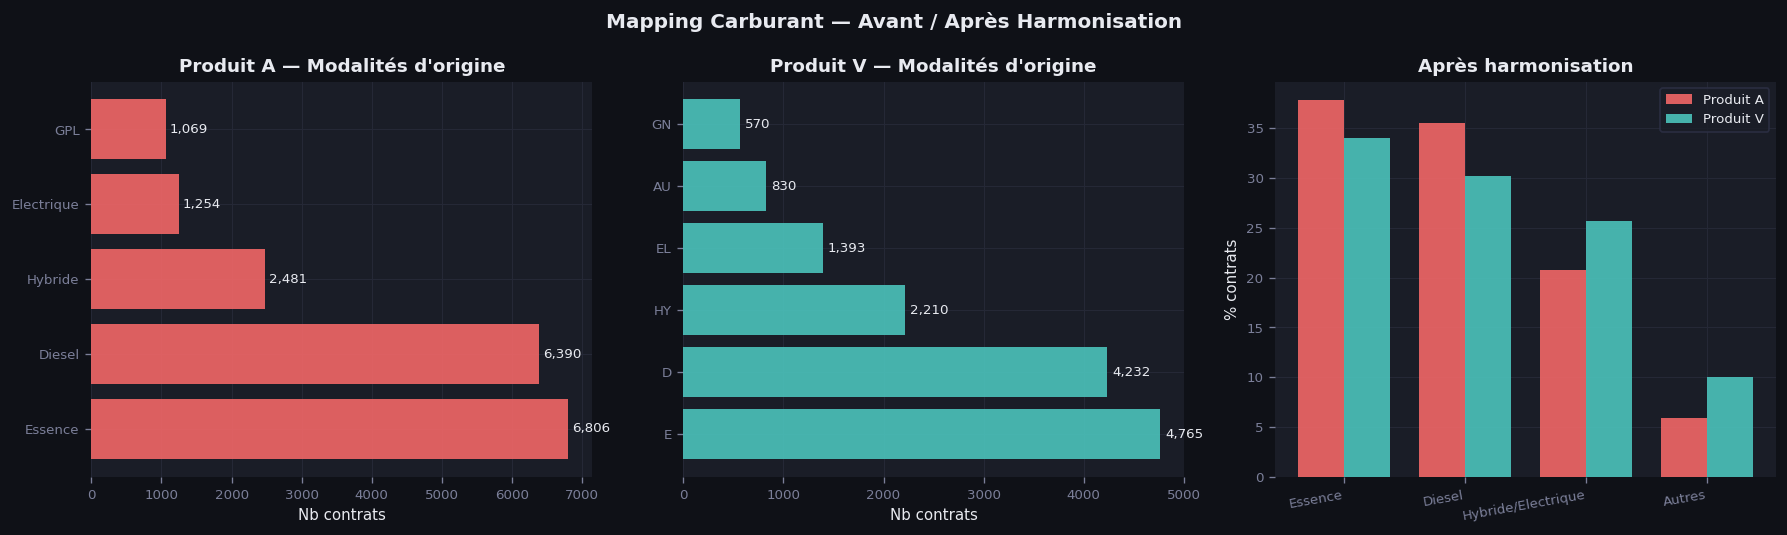

In [8]:
# Visualisation du mapping carburant
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Mapping Carburant — Avant / Après Harmonisation", fontsize=12, fontweight="bold")

# Modalités brutes A
cnt_brut_a = df_A["carburant"].value_counts()
axes[0].barh(cnt_brut_a.index, cnt_brut_a.values, color=A_MAIN, alpha=0.85)
axes[0].set_title("Produit A — Modalités d'origine")
axes[0].set_xlabel("Nb contrats")
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():,.0f}", va="center", fontsize=8)

# Modalités brutes V
cnt_brut_v = df_V["energie"].value_counts()
axes[1].barh(cnt_brut_v.index, cnt_brut_v.values, color=V_MAIN, alpha=0.85)
axes[1].set_title("Produit V — Modalités d'origine")
axes[1].set_xlabel("Nb contrats")
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():,.0f}", va="center", fontsize=8)

# Après harmonisation
h_a = df_A["carburant_h"].value_counts().reindex(CARB_ORDER).fillna(0)
h_v = df_V["carburant_h"].value_counts().reindex(CARB_ORDER).fillna(0)
x = np.arange(len(CARB_ORDER)); w = 0.38
axes[2].bar(x - w / 2, h_a / h_a.sum() * 100, w, color=A_MAIN, alpha=0.85, label="Produit A")
axes[2].bar(x + w / 2, h_v / h_v.sum() * 100, w, color=V_MAIN, alpha=0.85, label="Produit V")
axes[2].set_xticks(x)
axes[2].set_xticklabels(CARB_ORDER, rotation=10, ha="right")
axes[2].set_ylabel("% contrats")
axes[2].set_title("Après harmonisation")
axes[2].legend()

plt.tight_layout()
plt.show()


## 4. KPIs Globaux

On calcule les indicateurs techniques standards :
- **Fréquence** = nb sinistres / nb contrats
- **Sévérité** = charge totale / nb sinistres
- **S/P** = charge totale / prime acquise


In [9]:
def compute_kpis(df: pd.DataFrame) -> dict:
    """Calcule les KPIs techniques d'un portefeuille."""
    n   = len(df)
    p   = df["prime"].sum()
    s   = df["charge_sinistre"].sum()
    ns  = df["nb_sinistres"].sum()
    return {
        "nb_contrats":   n,
        "prime_totale":  p,
        "prime_moy":     p / n,
        "charge_totale": s,
        "nb_sinistres":  int(ns),
        "frequence":     ns / n,
        "severite":      s / ns if ns > 0 else 0.0,
        "sp_ratio":      s / p  if p  > 0 else 0.0,
    }

kpi_A = compute_kpis(df_A)
kpi_V = compute_kpis(df_V)

# ─── Tableau de synthèse ────────────────────────────────────────
kpi_df = pd.DataFrame({"Produit A": kpi_A, "Produit V": kpi_V}).T
kpi_df.index.name = "Produit"

# Formatage lisible
kpi_fmt = kpi_df.copy()
kpi_fmt["nb_contrats"]   = kpi_df["nb_contrats"].map("{:,.0f}".format)
kpi_fmt["prime_totale"]  = kpi_df["prime_totale"].map("{:,.0f} €".format)
kpi_fmt["prime_moy"]     = kpi_df["prime_moy"].map("{:.1f} €".format)
kpi_fmt["charge_totale"] = kpi_df["charge_totale"].map("{:,.0f} €".format)
kpi_fmt["nb_sinistres"]  = kpi_df["nb_sinistres"].map("{:,.0f}".format)
kpi_fmt["frequence"]     = kpi_df["frequence"].map("{:.4f}".format)
kpi_fmt["severite"]      = kpi_df["severite"].map("{:,.0f} €".format)
kpi_fmt["sp_ratio"]      = kpi_df["sp_ratio"].map("{:.2%}".format)

kpi_fmt


,nb_contrats,prime_totale,prime_moy,charge_totale,nb_sinistres,frequence,severite,sp_ratio
Produit,,,,,,,,
Produit A,"18,000","4,747,256 €",263.7 €,"6,128,678 €","1,567",0.0871,"3,911 €",129.10%
Produit V,"14,000","3,228,509 €",230.6 €,"4,308,613 €","1,105",0.0789,"3,899 €",133.46%


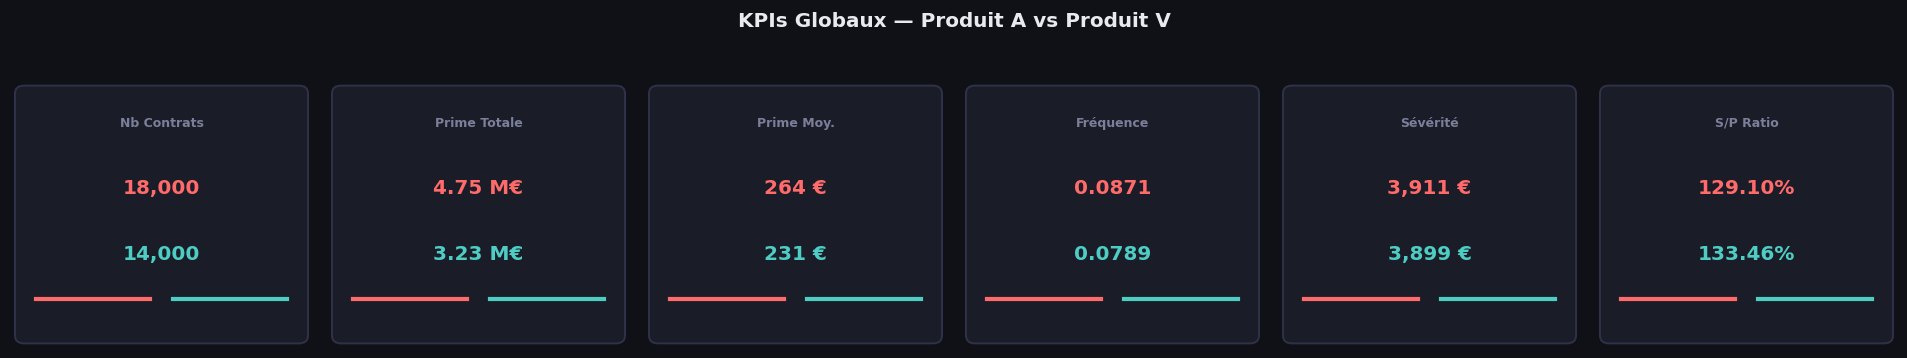

In [10]:
# ─── Dashboard KPIs globaux ─────────────────────────────────────
metrics = [
    ("Nb Contrats",   f"{kpi_A['nb_contrats']:,}",        f"{kpi_V['nb_contrats']:,}"),
    ("Prime Totale",  f"{kpi_A['prime_totale']/1e6:.2f} M€", f"{kpi_V['prime_totale']/1e6:.2f} M€"),
    ("Prime Moy.",    f"{kpi_A['prime_moy']:.0f} €",      f"{kpi_V['prime_moy']:.0f} €"),
    ("Fréquence",     f"{kpi_A['frequence']:.4f}",         f"{kpi_V['frequence']:.4f}"),
    ("Sévérité",      f"{kpi_A['severite']:,.0f} €",       f"{kpi_V['severite']:,.0f} €"),
    ("S/P Ratio",     f"{kpi_A['sp_ratio']:.2%}",          f"{kpi_V['sp_ratio']:.2%}"),
]

fig, axes = plt.subplots(1, 6, figsize=(16, 2.8))
fig.patch.set_facecolor(BG)
fig.suptitle("KPIs Globaux — Produit A vs Produit V",
             fontsize=12, fontweight="bold", y=1.05)

for ax, (label, va, vv) in zip(axes, metrics):
    ax.set_facecolor(PANEL)
    ax.axis("off")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    rect = FancyBboxPatch((0.04, 0.04), 0.92, 0.92,
        boxstyle="round,pad=0.03", linewidth=1.2,
        edgecolor=BORDER, facecolor=PANEL)
    ax.add_patch(rect)
    ax.text(0.5, 0.85, label, ha="center", va="center",
            color=MUTED, fontsize=7.5, fontweight="bold")
    ax.text(0.5, 0.60, va, ha="center", va="center",
            color=A_MAIN, fontsize=12, fontweight="bold")
    ax.text(0.5, 0.35, vv, ha="center", va="center",
            color=V_MAIN, fontsize=12, fontweight="bold")
    ax.plot([0.08, 0.46], [0.18, 0.18], color=A_MAIN, linewidth=2.5,
            transform=ax.transAxes, clip_on=False)
    ax.plot([0.54, 0.92], [0.18, 0.18], color=V_MAIN, linewidth=2.5,
            transform=ax.transAxes, clip_on=False)

plt.tight_layout()
plt.show()


## 5. KPIs par Garantie

On segmente chaque portefeuille par **garantie harmonisée** et on compare  
les indicateurs techniques garantie par garantie.


In [11]:
def kpis_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """
    Calcule les KPIs techniques par groupe (garantie, carburant, etc.).
    Retourne un DataFrame trié par s/p décroissant.
    """
    rows = []
    for val, grp in df.groupby(group_col):
        k = compute_kpis(grp)
        k[group_col] = val
        rows.append(k)
    result = pd.DataFrame(rows).set_index(group_col)
    result = result.reindex([g for g in GAR_ORDER if g in result.index]
                            + [g for g in result.index if g not in GAR_ORDER])
    return result


kpi_gar_A = kpis_by_group(df_A, "garantie_h")
kpi_gar_V = kpis_by_group(df_V, "garantie_h")

print("── Produit A — KPIs par garantie ──")
display(kpi_gar_A[["nb_contrats", "prime_moy", "frequence", "severite", "sp_ratio"]]
        .style
        .format({
            "nb_contrats": "{:,.0f}",
            "prime_moy":   "{:.1f} €",
            "frequence":   "{:.4f}",
            "severite":    "{:,.0f} €",
            "sp_ratio":    "{:.2%}",
        })
        .background_gradient(subset=["sp_ratio"], cmap="RdYlGn_r"))


── Produit A — KPIs par garantie ──


,nb_contrats,prime_moy,frequence,severite,sp_ratio
garantie_h,,,,,
RC,"5,427",284.3 €,0.0698,"4,365 €",107.25%
Dommages,"5,104",457.1 €,0.0929,"7,047 €",143.16%
Vol,"2,677",182.2 €,0.0448,"8,153 €",200.58%
Bris de Glace,"3,023",90.9 €,0.1085,328 €,39.10%
Assistance,"1,769",61.4 €,0.1504,181 €,44.27%


In [12]:
print("── Produit V — KPIs par garantie ──")
display(kpi_gar_V[["nb_contrats", "prime_moy", "frequence", "severite", "sp_ratio"]]
        .style
        .format({
            "nb_contrats": "{:,.0f}",
            "prime_moy":   "{:.1f} €",
            "frequence":   "{:.4f}",
            "severite":    "{:,.0f} €",
            "sp_ratio":    "{:.2%}",
        })
        .background_gradient(subset=["sp_ratio"], cmap="RdYlGn_r"))


── Produit V — KPIs par garantie ──


,nb_contrats,prime_moy,frequence,severite,sp_ratio
garantie_h,,,,,
RC,"3,905",257.6 €,0.0545,"4,850 €",102.70%
Dommages,"3,699",416.3 €,0.0887,"6,846 €",145.84%
Vol,"1,957",186.7 €,0.0491,"9,349 €",245.63%
Bris de Glace,"2,175",93.7 €,0.0966,294 €,30.30%
Assistance,"1,241",54.6 €,0.1547,171 €,48.57%
Protection Juridique,"1,023",44.8 €,0.0645,573 €,82.50%


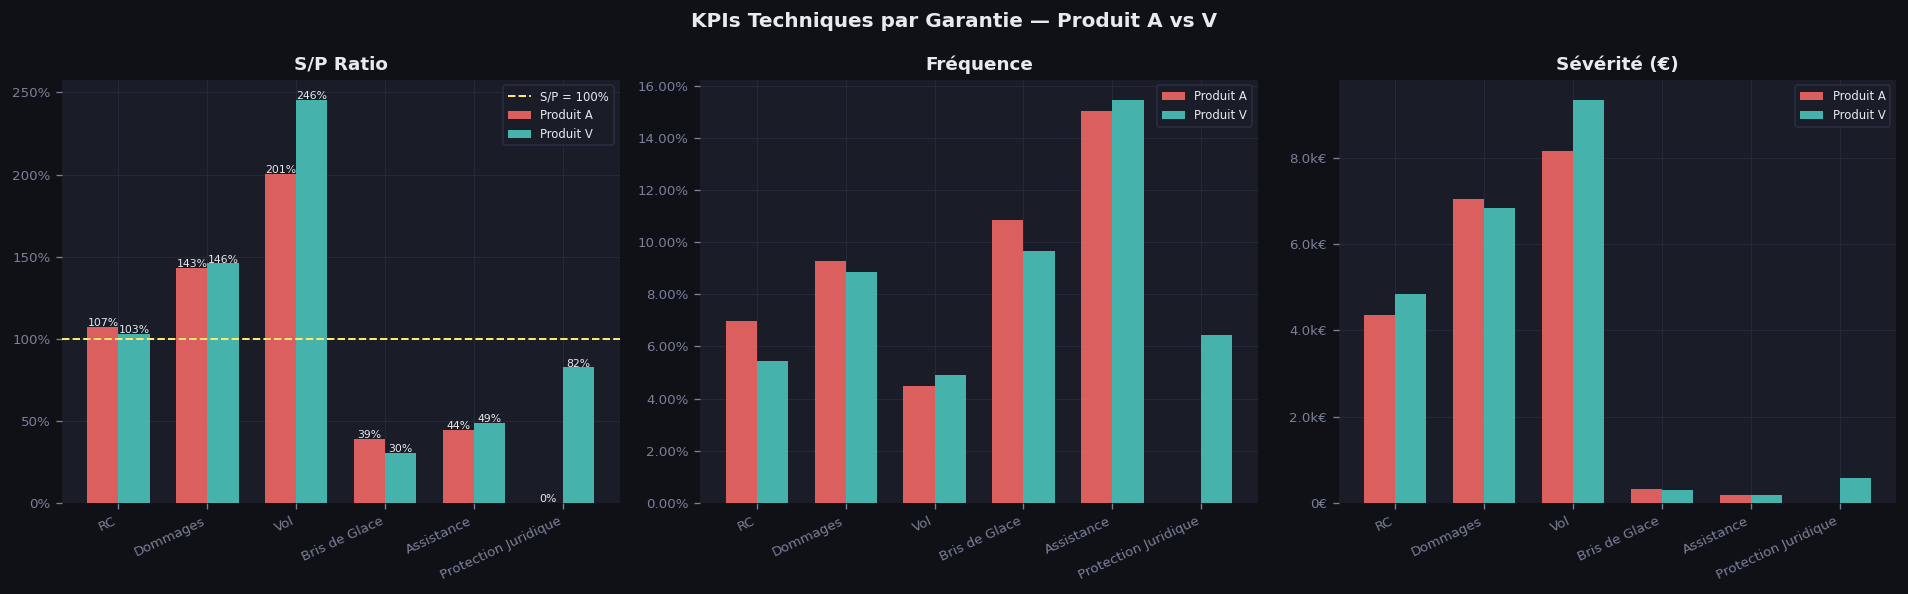

In [13]:
gars_all = [g for g in GAR_ORDER
            if g in kpi_gar_A.index or g in kpi_gar_V.index]
x = np.arange(len(gars_all))
w = 0.35

def safe_get(df_kpi, gar, col):
    return df_kpi.loc[gar, col] if gar in df_kpi.index else 0.0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("KPIs Techniques par Garantie — Produit A vs V",
             fontsize=12, fontweight="bold")

kpi_plots = [
    ("sp_ratio",   "S/P Ratio",          "fmt_pct"),
    ("frequence",  "Fréquence",          "fmt_pct"),
    ("severite",   "Sévérité (€)",       "fmt_eur"),
]

for ax, (col, title, fmt) in zip(axes, kpi_plots):
    vals_a = [safe_get(kpi_gar_A, g, col) for g in gars_all]
    vals_v = [safe_get(kpi_gar_V, g, col) for g in gars_all]
    bars_a = ax.bar(x - w / 2, vals_a, w, color=A_MAIN, alpha=0.85, label="Produit A")
    bars_v = ax.bar(x + w / 2, vals_v, w, color=V_MAIN, alpha=0.85, label="Produit V")

    if col == "sp_ratio":
        ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.2, label="S/P = 100%")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
        for b, v in zip(bars_a, vals_a):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f"{v:.0%}", ha="center", fontsize=6.5, color=TEXT)
        for b, v in zip(bars_v, vals_v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f"{v:.0%}", ha="center", fontsize=6.5, color=TEXT)
    elif col == "frequence":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"{v/1000:.1f}k€" if v >= 1000 else f"{v:.0f}€")
        )

    ax.set_xticks(x)
    ax.set_xticklabels(gars_all, rotation=25, ha="right", fontsize=8)
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


## 6. Analyse Univariée — Tranche d'Âge

Le **Produit A** code l'âge en tranches dès la source.  
Le **Produit V** stocke l'âge brut, que l'on a converti en tranches identiques (§3).  
On analyse distribution, fréquence, sévérité, prime et S/P par tranche.


In [14]:
# ─── Calcul des métriques par tranche d'âge ────────────────────
def kpis_by_age(df):
    g = df.groupby("age_tranche_h", observed=False)
    freq = g.apply(lambda x: x["nb_sinistres"].sum() / len(x))
    sev  = (df[df["nb_sinistres"] > 0]
              .groupby("age_tranche_h", observed=False)["charge_sinistre"].median())
    sp   = g.apply(lambda x: x["charge_sinistre"].sum() / x["prime"].sum())
    pm   = g["prime"].mean()
    cnt  = g.size()
    return pd.DataFrame({
        "pct_contrats": cnt / cnt.sum() * 100,
        "prime_moy":    pm,
        "frequence":    freq,
        "severite_med": sev,
        "sp_ratio":     sp,
    }).reindex(AGE_ORDER)

age_A = kpis_by_age(df_A)
age_V = kpis_by_age(df_V)

display(age_A.style.format({
    "pct_contrats": "{:.1f}%",
    "prime_moy":    "{:.0f} €",
    "frequence":    "{:.4f}",
    "severite_med": "{:,.0f} €",
    "sp_ratio":     "{:.2%}",
}).background_gradient(subset=["sp_ratio"], cmap="RdYlGn_r").set_caption("Produit A — par tranche d'âge"))


,pct_contrats,prime_moy,frequence,severite_med,sp_ratio
age_tranche_h,,,,,
18-25,10.0%,343 €,0.1302,"2,401 €",147.26%
26-35,22.4%,254 €,0.0774,"2,273 €",118.16%
36-45,24.7%,254 €,0.0792,"2,356 €",110.29%
46-55,22.1%,252 €,0.0826,"2,165 €",133.81%
56-65,13.8%,260 €,0.0932,"2,647 €",148.82%
65+,7.0%,260 €,0.0862,"3,294 €",140.70%


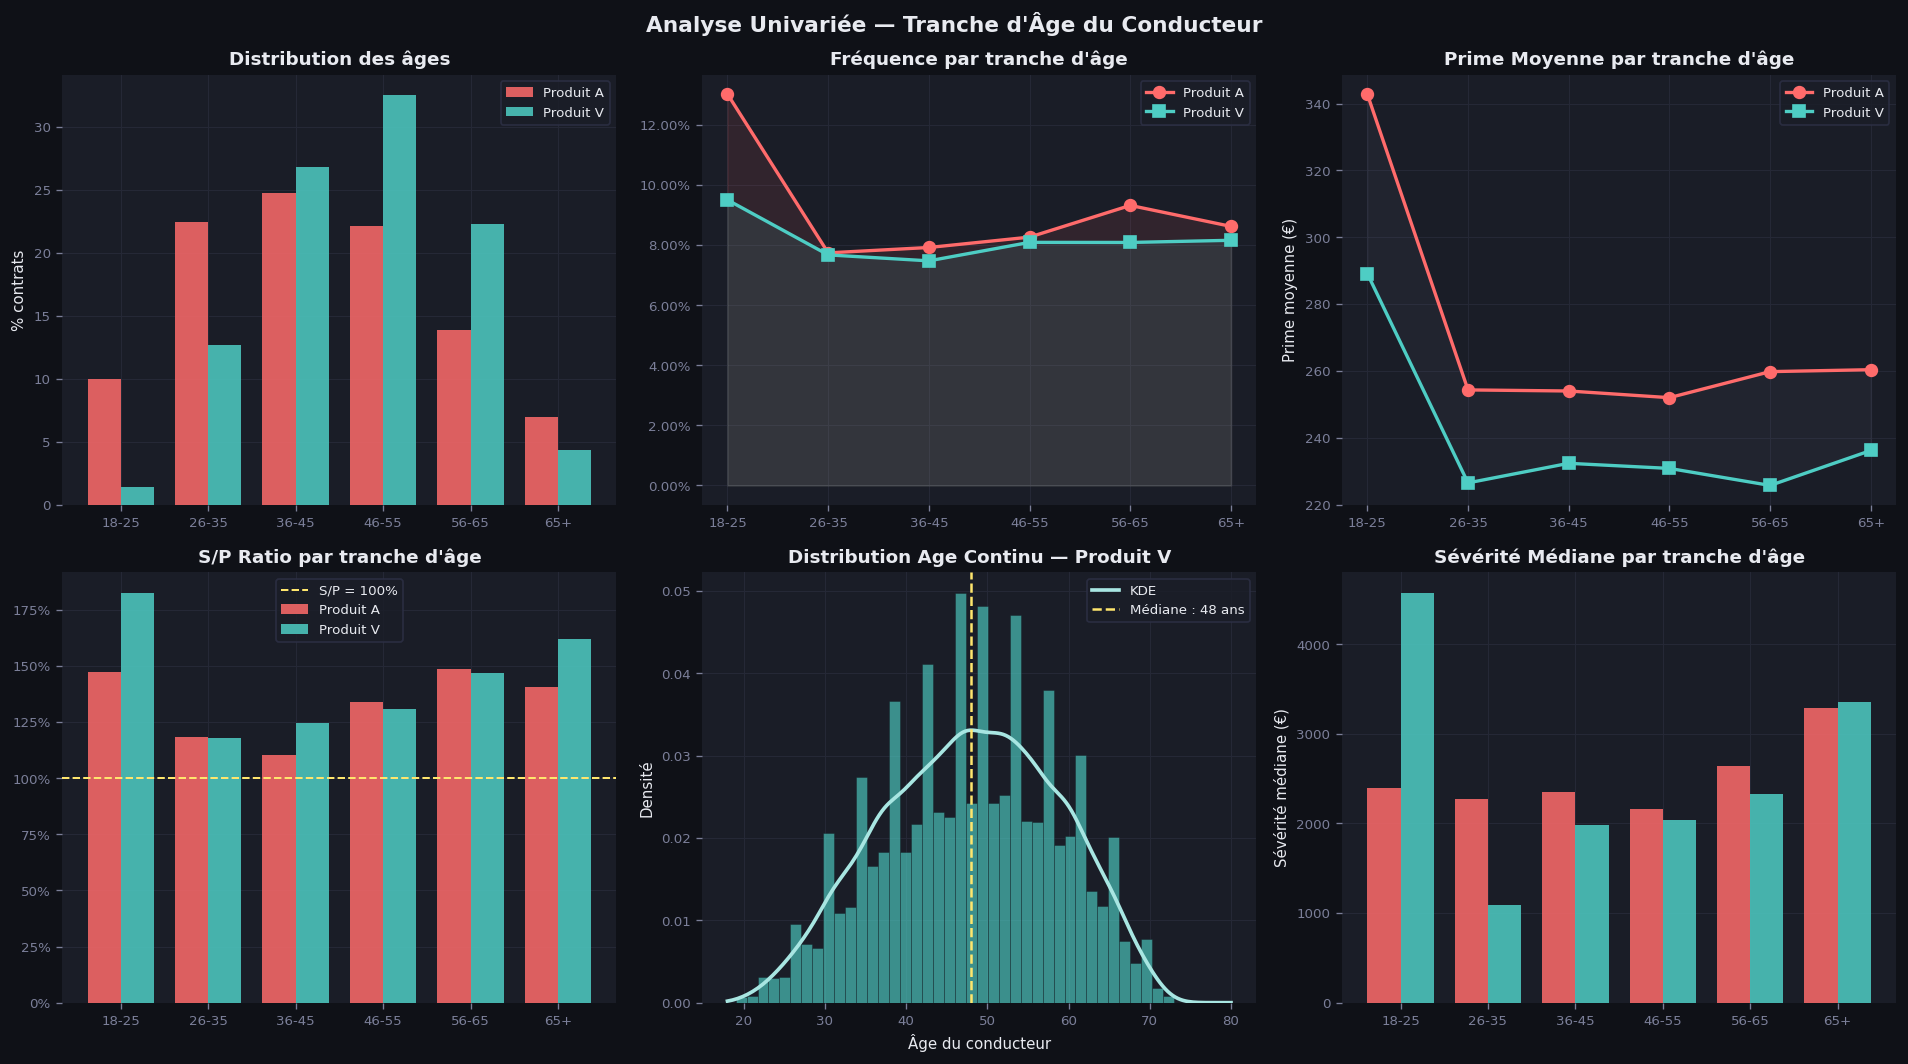

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Analyse Univariée — Tranche d'Âge du Conducteur",
             fontsize=13, fontweight="bold")

x = np.arange(len(AGE_ORDER)); w = 0.38

# 1. Distribution
ax = axes[0, 0]
ax.bar(x - w / 2, age_A["pct_contrats"], w, color=A_MAIN, alpha=0.85, label="Produit A")
ax.bar(x + w / 2, age_V["pct_contrats"], w, color=V_MAIN, alpha=0.85, label="Produit V")
ax.set_xticks(x); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("% contrats"); ax.set_title("Distribution des âges"); ax.legend()

# 2. Fréquence (courbes)
ax = axes[0, 1]
ax.plot(AGE_ORDER, age_A["frequence"], "o-", color=A_MAIN, lw=2, ms=7, label="Produit A")
ax.plot(AGE_ORDER, age_V["frequence"], "s-", color=V_MAIN, lw=2, ms=7, label="Produit V")
ax.fill_between(range(len(AGE_ORDER)), age_A["frequence"], alpha=0.10, color=A_MAIN)
ax.fill_between(range(len(AGE_ORDER)), age_V["frequence"], alpha=0.10, color=V_MAIN)
ax.set_xticks(range(len(AGE_ORDER))); ax.set_xticklabels(AGE_ORDER)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_title("Fréquence par tranche d'âge"); ax.legend()

# 3. Prime moyenne (courbes)
ax = axes[0, 2]
ax.plot(AGE_ORDER, age_A["prime_moy"], "o-", color=A_MAIN, lw=2, ms=7, label="Produit A")
ax.plot(AGE_ORDER, age_V["prime_moy"], "s-", color=V_MAIN, lw=2, ms=7, label="Produit V")
ax.fill_between(range(len(AGE_ORDER)), age_A["prime_moy"], age_V["prime_moy"],
                alpha=0.08, color=MUTED)
ax.set_xticks(range(len(AGE_ORDER))); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("Prime moyenne (€)"); ax.set_title("Prime Moyenne par tranche d'âge"); ax.legend()

# 4. S/P ratio
ax = axes[1, 0]
ax.bar(x - w / 2, age_A["sp_ratio"], w, color=A_MAIN, alpha=0.85, label="Produit A")
ax.bar(x + w / 2, age_V["sp_ratio"], w, color=V_MAIN, alpha=0.85, label="Produit V")
ax.axhline(1.0, color=ACCENT, linestyle="--", lw=1.2, label="S/P = 100%")
ax.set_xticks(x); ax.set_xticklabels(AGE_ORDER)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("S/P Ratio par tranche d'âge"); ax.legend()

# 5. Distribution continue de l'âge (Produit V uniquement)
ax = axes[1, 1]
ax.hist(df_V["age_conducteur"], bins=40, color=V_MAIN, alpha=0.65,
        density=True, edgecolor=BG, linewidth=0.3)
kde = stats.gaussian_kde(df_V["age_conducteur"])
x_k = np.linspace(18, 80, 200)
ax.plot(x_k, kde(x_k), color=V_LIGHT, linewidth=2.2, label="KDE")
ax.axvline(df_V["age_conducteur"].median(), color=ACCENT, linestyle="--",
           lw=1.5, label=f"Médiane : {df_V['age_conducteur'].median():.0f} ans")
ax.set_xlabel("Âge du conducteur"); ax.set_ylabel("Densité")
ax.set_title("Distribution Age Continu — Produit V"); ax.legend()

# 6. Sévérité médiane
ax = axes[1, 2]
ax.bar(x - w / 2, age_A["severite_med"].fillna(0), w, color=A_MAIN, alpha=0.85)
ax.bar(x + w / 2, age_V["severite_med"].fillna(0), w, color=V_MAIN, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("Sévérité médiane (€)"); ax.set_title("Sévérité Médiane par tranche d'âge")

plt.tight_layout()
plt.show()


## 7. Analyse Univariée — Carburant

On analyse d'abord les **modalités brutes** de chaque produit,  
puis les indicateurs sur les **modalités harmonisées**.


In [16]:
# ─── Métriques par carburant harmonisé ─────────────────────────
def kpis_by_col(df, col, order=None):
    g = df.groupby(col)
    freq = g.apply(lambda x: x["nb_sinistres"].sum() / len(x))
    sp   = g.apply(lambda x: x["charge_sinistre"].sum() / x["prime"].sum())
    pm   = g["prime"].mean()
    cnt  = g.size()
    result = pd.DataFrame({
        "pct_contrats": cnt / cnt.sum() * 100,
        "prime_moy":    pm,
        "frequence":    freq,
        "sp_ratio":     sp,
    })
    if order:
        result = result.reindex([v for v in order if v in result.index]
                                + [v for v in result.index if v not in order])
    return result

carb_A = kpis_by_col(df_A, "carburant_h", CARB_ORDER)
carb_V = kpis_by_col(df_V, "carburant_h", CARB_ORDER)

print("Produit A — carburant harmonisé")
display(carb_A.style.format({
    "pct_contrats": "{:.1f}%", "prime_moy": "{:.0f} €",
    "frequence": "{:.4f}", "sp_ratio": "{:.2%}"
}).background_gradient(subset=["sp_ratio"], cmap="RdYlGn_r"))


Produit A — carburant harmonisé


,pct_contrats,prime_moy,frequence,sp_ratio
carburant_h,,,,
Essence,37.8%,271 €,0.0887,129.21%
Diesel,35.5%,265 €,0.0883,122.60%
Hybride/Electrique,20.8%,247 €,0.0782,133.10%
Autres,5.9%,265 €,0.1001,154.18%


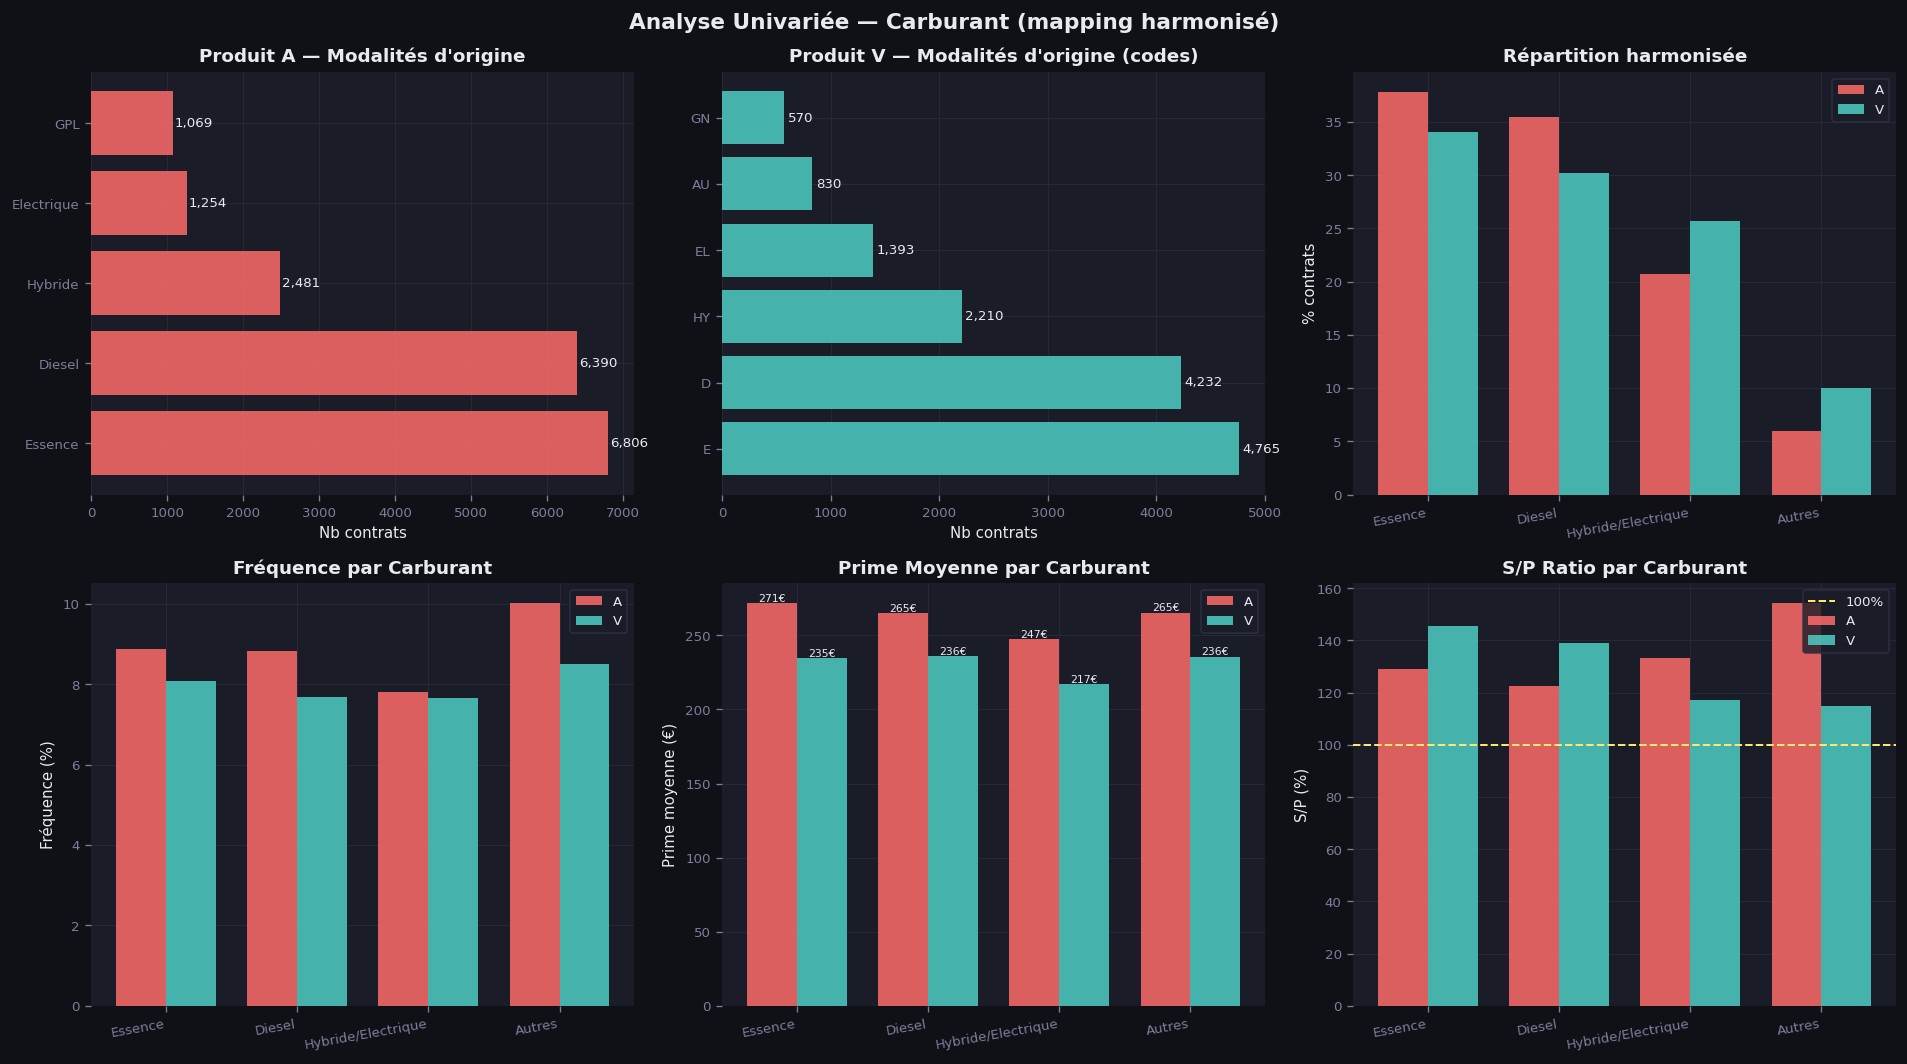

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Analyse Univariée — Carburant (mapping harmonisé)",
             fontsize=13, fontweight="bold")

# 1. Modalités brutes A
cnt_ba = df_A["carburant"].value_counts()
axes[0, 0].barh(cnt_ba.index, cnt_ba.values, color=A_MAIN, alpha=0.85)
axes[0, 0].set_title("Produit A — Modalités d'origine")
axes[0, 0].set_xlabel("Nb contrats")
for bar in axes[0, 0].patches:
    axes[0, 0].text(bar.get_width() + 30,
                    bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():,.0f}", va="center", fontsize=8)

# 2. Modalités brutes V
cnt_bv = df_V["energie"].value_counts()
axes[0, 1].barh(cnt_bv.index, cnt_bv.values, color=V_MAIN, alpha=0.85)
axes[0, 1].set_title("Produit V — Modalités d'origine (codes)")
axes[0, 1].set_xlabel("Nb contrats")
for bar in axes[0, 1].patches:
    axes[0, 1].text(bar.get_width() + 30,
                    bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():,.0f}", va="center", fontsize=8)

# 3. Distribution harmonisée
x = np.arange(len(CARB_ORDER)); w = 0.38
axes[0, 2].bar(x - w / 2, carb_A["pct_contrats"], w, color=A_MAIN, alpha=0.85, label="A")
axes[0, 2].bar(x + w / 2, carb_V["pct_contrats"], w, color=V_MAIN, alpha=0.85, label="V")
axes[0, 2].set_xticks(x); axes[0, 2].set_xticklabels(CARB_ORDER, rotation=10, ha="right")
axes[0, 2].set_ylabel("% contrats"); axes[0, 2].set_title("Répartition harmonisée"); axes[0, 2].legend()

# 4. Fréquence
axes[1, 0].bar(x - w / 2, carb_A["frequence"] * 100, w, color=A_MAIN, alpha=0.85, label="A")
axes[1, 0].bar(x + w / 2, carb_V["frequence"] * 100, w, color=V_MAIN, alpha=0.85, label="V")
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(CARB_ORDER, rotation=10, ha="right")
axes[1, 0].set_ylabel("Fréquence (%)"); axes[1, 0].set_title("Fréquence par Carburant"); axes[1, 0].legend()

# 5. Prime moyenne
bars_a = axes[1, 1].bar(x - w / 2, carb_A["prime_moy"], w, color=A_MAIN, alpha=0.85, label="A")
bars_v = axes[1, 1].bar(x + w / 2, carb_V["prime_moy"], w, color=V_MAIN, alpha=0.85, label="V")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(CARB_ORDER, rotation=10, ha="right")
axes[1, 1].set_ylabel("Prime moyenne (€)"); axes[1, 1].set_title("Prime Moyenne par Carburant"); axes[1, 1].legend()
for b, v in zip(bars_a, carb_A["prime_moy"]):
    axes[1, 1].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}€",
                    ha="center", fontsize=6.5, color=TEXT)
for b, v in zip(bars_v, carb_V["prime_moy"]):
    axes[1, 1].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}€",
                    ha="center", fontsize=6.5, color=TEXT)

# 6. S/P
axes[1, 2].bar(x - w / 2, carb_A["sp_ratio"] * 100, w, color=A_MAIN, alpha=0.85, label="A")
axes[1, 2].bar(x + w / 2, carb_V["sp_ratio"] * 100, w, color=V_MAIN, alpha=0.85, label="V")
axes[1, 2].axhline(100, color=ACCENT, linestyle="--", lw=1.2, label="100%")
axes[1, 2].set_xticks(x); axes[1, 2].set_xticklabels(CARB_ORDER, rotation=10, ha="right")
axes[1, 2].set_ylabel("S/P (%)"); axes[1, 2].set_title("S/P Ratio par Carburant"); axes[1, 2].legend()

plt.tight_layout()
plt.show()


## 8. Analyse Univariée — Usage & Ancienneté Permis


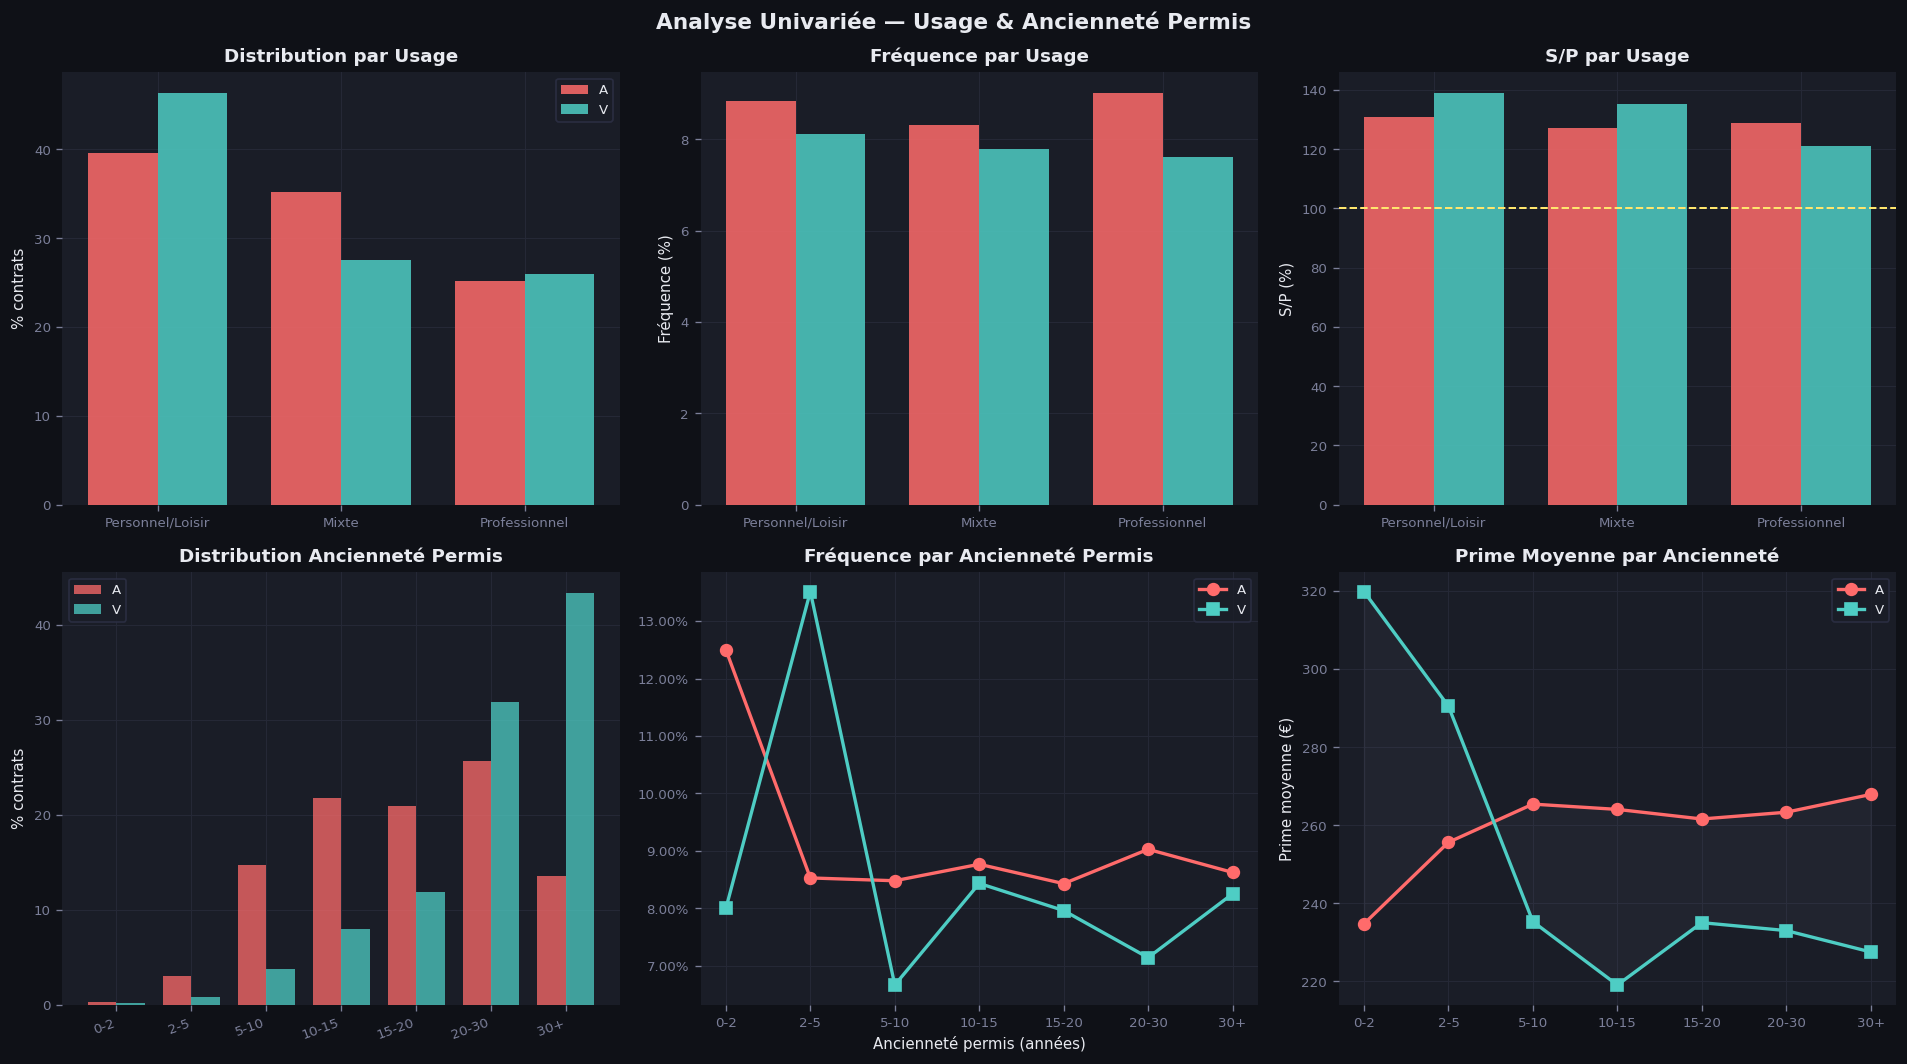

In [18]:
usage_A = kpis_by_col(df_A, "usage_h", USAGE_ORDER)
usage_V = kpis_by_col(df_V, "usage_h", USAGE_ORDER)

# ─── Binning ancienneté ─────────────────────────────────────────
ANC_BINS   = [0, 2, 5, 10, 15, 20, 30, 46]
ANC_LABELS = ["0-2", "2-5", "5-10", "10-15", "15-20", "20-30", "30+"]

df_A["anc_bin"] = pd.cut(df_A["anciennete_permis"], bins=ANC_BINS, labels=ANC_LABELS)
df_V["anc_bin"] = pd.cut(df_V["annees_permis"],     bins=ANC_BINS, labels=ANC_LABELS)

anc_A = kpis_by_col(df_A, "anc_bin", ANC_LABELS)
anc_V = kpis_by_col(df_V, "anc_bin", ANC_LABELS)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Analyse Univariée — Usage & Ancienneté Permis",
             fontsize=13, fontweight="bold")

xu = np.arange(len(USAGE_ORDER)); w = 0.38

# 1. Distribution usage
axes[0, 0].bar(xu - w/2, usage_A["pct_contrats"], w, color=A_MAIN, alpha=0.85, label="A")
axes[0, 0].bar(xu + w/2, usage_V["pct_contrats"], w, color=V_MAIN, alpha=0.85, label="V")
axes[0, 0].set_xticks(xu); axes[0, 0].set_xticklabels(USAGE_ORDER)
axes[0, 0].set_ylabel("% contrats"); axes[0, 0].set_title("Distribution par Usage"); axes[0, 0].legend()

# 2. Fréquence par usage
axes[0, 1].bar(xu - w/2, usage_A["frequence"] * 100, w, color=A_MAIN, alpha=0.85)
axes[0, 1].bar(xu + w/2, usage_V["frequence"] * 100, w, color=V_MAIN, alpha=0.85)
axes[0, 1].set_xticks(xu); axes[0, 1].set_xticklabels(USAGE_ORDER)
axes[0, 1].set_ylabel("Fréquence (%)"); axes[0, 1].set_title("Fréquence par Usage")

# 3. S/P par usage
axes[0, 2].bar(xu - w/2, usage_A["sp_ratio"] * 100, w, color=A_MAIN, alpha=0.85)
axes[0, 2].bar(xu + w/2, usage_V["sp_ratio"] * 100, w, color=V_MAIN, alpha=0.85)
axes[0, 2].axhline(100, color=ACCENT, linestyle="--", lw=1.2)
axes[0, 2].set_xticks(xu); axes[0, 2].set_xticklabels(USAGE_ORDER)
axes[0, 2].set_ylabel("S/P (%)"); axes[0, 2].set_title("S/P par Usage")

# 4. Distribution ancienneté (histogramme superposé)
xa = np.arange(len(ANC_LABELS)); w2 = 0.38
axes[1, 0].bar(xa - w2/2, anc_A["pct_contrats"], w2, color=A_MAIN, alpha=0.75, label="A")
axes[1, 0].bar(xa + w2/2, anc_V["pct_contrats"], w2, color=V_MAIN, alpha=0.75, label="V")
axes[1, 0].set_xticks(xa); axes[1, 0].set_xticklabels(ANC_LABELS, rotation=20, ha="right")
axes[1, 0].set_ylabel("% contrats"); axes[1, 0].set_title("Distribution Ancienneté Permis"); axes[1, 0].legend()

# 5. Fréquence par ancienneté
axes[1, 1].plot(ANC_LABELS, anc_A["frequence"], "o-", color=A_MAIN, lw=2, ms=7, label="A")
axes[1, 1].plot(ANC_LABELS, anc_V["frequence"], "s-", color=V_MAIN, lw=2, ms=7, label="V")
axes[1, 1].set_xlabel("Ancienneté permis (années)")
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
axes[1, 1].set_title("Fréquence par Ancienneté Permis"); axes[1, 1].legend()

# 6. Prime moyenne par ancienneté
axes[1, 2].plot(ANC_LABELS, anc_A["prime_moy"], "o-", color=A_MAIN, lw=2, ms=7, label="A")
axes[1, 2].plot(ANC_LABELS, anc_V["prime_moy"], "s-", color=V_MAIN, lw=2, ms=7, label="V")
axes[1, 2].fill_between(range(len(ANC_LABELS)),
                         anc_A["prime_moy"], anc_V["prime_moy"],
                         alpha=0.08, color=MUTED)
axes[1, 2].set_ylabel("Prime moyenne (€)"); axes[1, 2].set_title("Prime Moyenne par Ancienneté"); axes[1, 2].legend()

plt.tight_layout()
plt.show()


## 9. Analyse Bivariée

On croise les variables deux à deux pour détecter des **effets d'interaction**  
non visibles en analyse univariée.


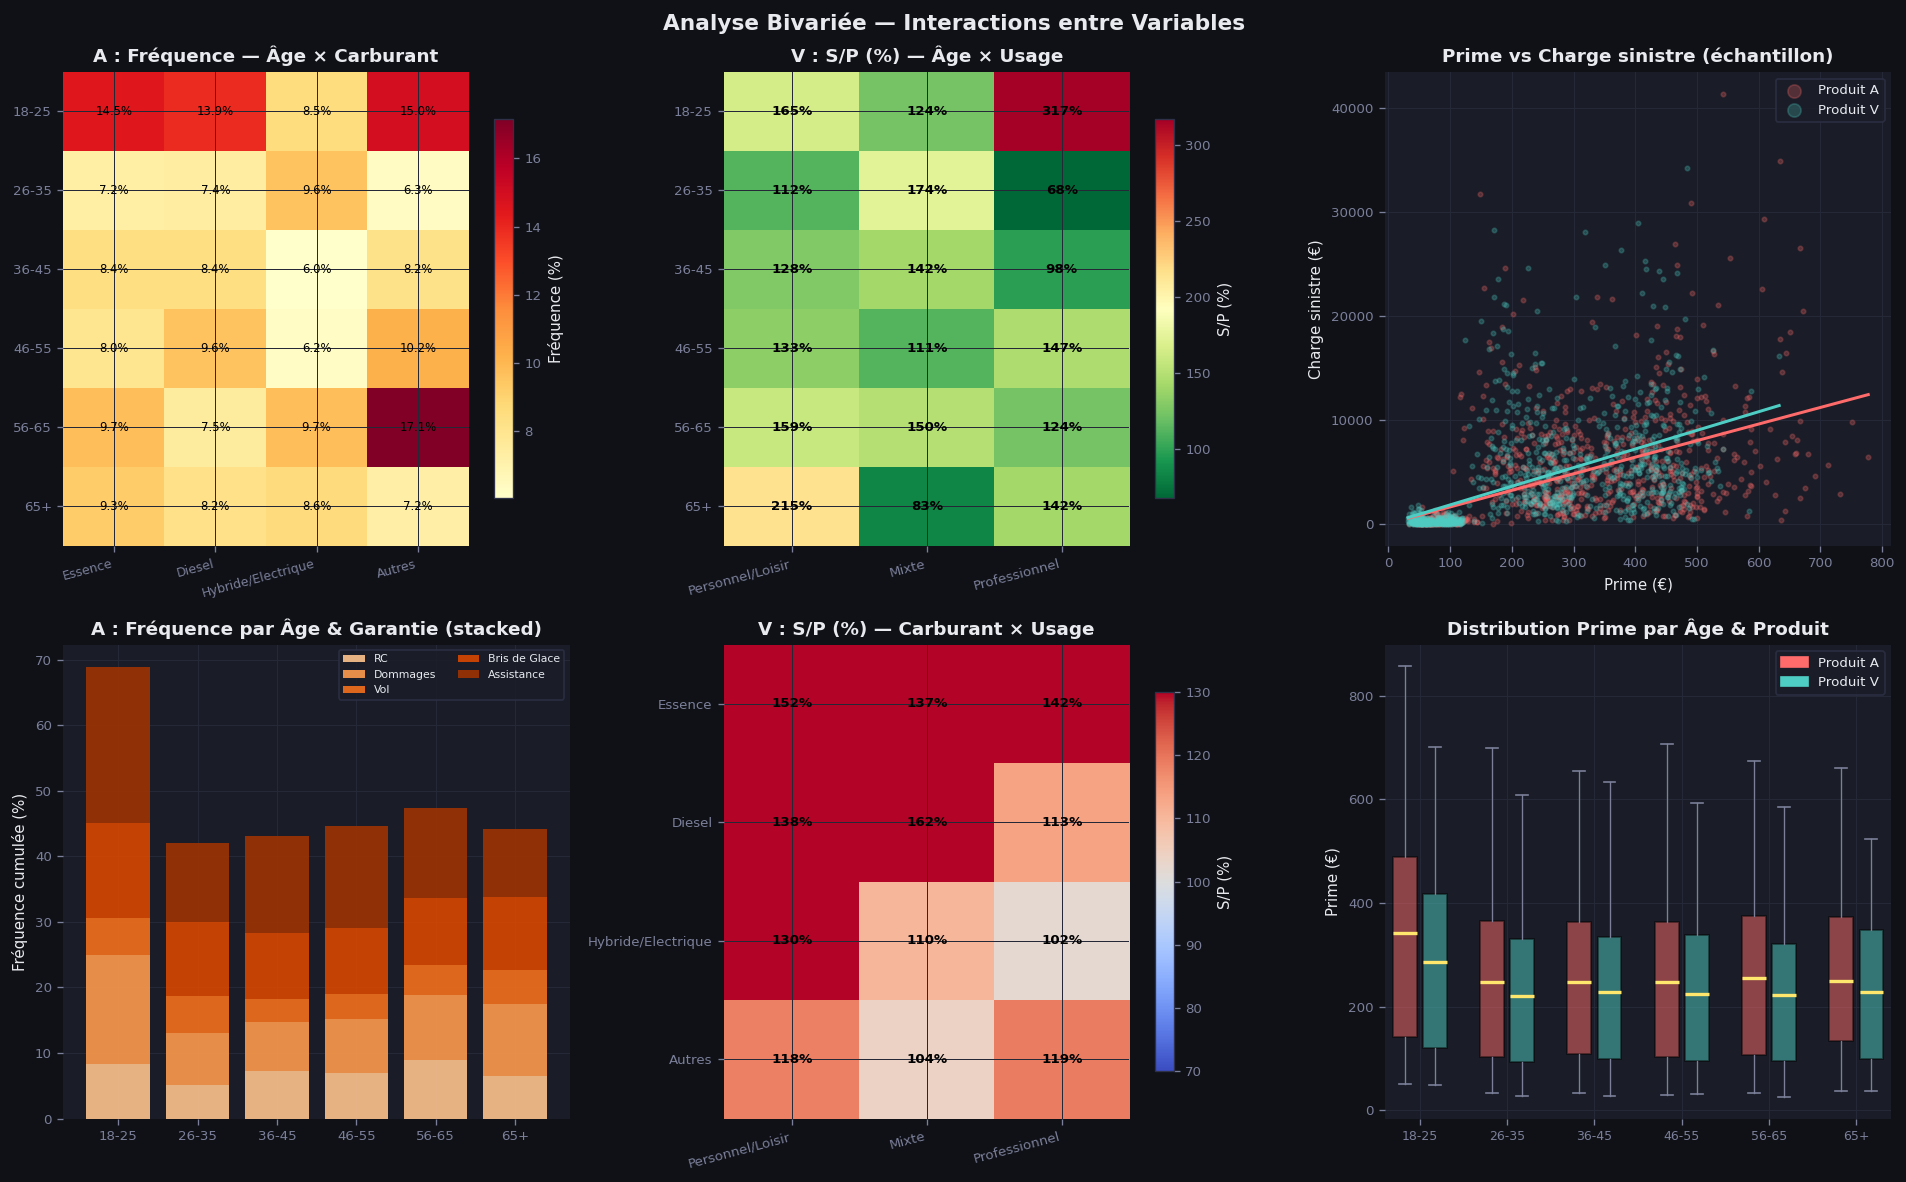

In [19]:
def pivot_kpi(df, row, col, kpi_fn, order_row=None, order_col=None):
    """
    Construit un tableau croisé d'un KPI calculé par (row × col).
    kpi_fn : fonction groupe → scalaire
    """
    tbl = df.groupby([row, col]).apply(kpi_fn).unstack(col)
    if order_row: tbl = tbl.reindex([r for r in order_row if r in tbl.index])
    if order_col: tbl = tbl.reindex([c for c in order_col if c in tbl.columns], axis=1)
    return tbl

# ─── Heatmaps ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Analyse Bivariée — Interactions entre Variables",
             fontsize=13, fontweight="bold")

# 1. Heatmap Fréquence : Âge × Carburant (Produit A)
piv1 = pivot_kpi(
    df_A, "age_tranche_h", "carburant_h",
    lambda x: x["nb_sinistres"].sum() / len(x) * 100,
    AGE_ORDER, CARB_ORDER
)
im1 = axes[0, 0].imshow(piv1.values, cmap="YlOrRd", aspect="auto")
axes[0, 0].set_xticks(range(len(piv1.columns)))
axes[0, 0].set_xticklabels(piv1.columns, rotation=15, ha="right", fontsize=7.5)
axes[0, 0].set_yticks(range(len(piv1.index)))
axes[0, 0].set_yticklabels(piv1.index, fontsize=8)
for i in range(piv1.shape[0]):
    for j in range(piv1.shape[1]):
        v = piv1.values[i, j]
        if not np.isnan(v):
            axes[0, 0].text(j, i, f"{v:.1f}%", ha="center", va="center",
                            fontsize=7, color="black")
plt.colorbar(im1, ax=axes[0, 0], shrink=0.8, label="Fréquence (%)")
axes[0, 0].set_title("A : Fréquence — Âge × Carburant")

# 2. Heatmap S/P : Âge × Usage (Produit V)
piv2 = pivot_kpi(
    df_V, "age_tranche_h", "usage_h",
    lambda x: x["charge_sinistre"].sum() / x["prime"].sum() * 100,
    AGE_ORDER, USAGE_ORDER
)
im2 = axes[0, 1].imshow(piv2.values, cmap="RdYlGn_r", aspect="auto")
axes[0, 1].set_xticks(range(len(piv2.columns)))
axes[0, 1].set_xticklabels(piv2.columns, rotation=15, ha="right", fontsize=8)
axes[0, 1].set_yticks(range(len(piv2.index)))
axes[0, 1].set_yticklabels(piv2.index, fontsize=8)
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]):
        v = piv2.values[i, j]
        if not np.isnan(v):
            axes[0, 1].text(j, i, f"{v:.0f}%", ha="center", va="center",
                            fontsize=8, color="black", fontweight="bold")
plt.colorbar(im2, ax=axes[0, 1], shrink=0.8, label="S/P (%)")
axes[0, 1].set_title("V : S/P (%) — Âge × Usage")

# 3. Scatter Prime vs Charge (sinistres uniquement)
samp_a = df_A[df_A["charge_sinistre"] > 0].sample(min(1000, df_A[df_A["charge_sinistre"] > 0].shape[0]), random_state=1)
samp_v = df_V[df_V["charge_sinistre"] > 0].sample(min(1000, df_V[df_V["charge_sinistre"] > 0].shape[0]), random_state=1)
axes[0, 2].scatter(samp_a["prime"], samp_a["charge_sinistre"],
                   alpha=0.25, s=7, color=A_MAIN, label="Produit A")
axes[0, 2].scatter(samp_v["prime"], samp_v["charge_sinistre"],
                   alpha=0.25, s=7, color=V_MAIN, label="Produit V")
for df_s, c in [(samp_a, A_MAIN), (samp_v, V_MAIN)]:
    m, b = np.polyfit(df_s["prime"], df_s["charge_sinistre"], 1)
    xf = np.linspace(df_s["prime"].min(), df_s["prime"].max(), 100)
    axes[0, 2].plot(xf, m * xf + b, color=c, linewidth=1.8)
axes[0, 2].set_xlabel("Prime (€)"); axes[0, 2].set_ylabel("Charge sinistre (€)")
axes[0, 2].set_title("Prime vs Charge sinistre (échantillon)"); axes[0, 2].legend(markerscale=3)

# 4. Fréquence empilée Âge × Garantie (Produit A)
freq_ag = (df_A.groupby(["age_tranche_h", "garantie_h"])
             .apply(lambda x: x["nb_sinistres"].sum() / len(x))
             .unstack("garantie_h")
             .reindex(AGE_ORDER))
freq_ag = freq_ag[[c for c in GAR_ORDER if c in freq_ag.columns]]
bottom = np.zeros(len(AGE_ORDER))
colors_stack = plt.cm.Oranges(np.linspace(0.3, 0.9, freq_ag.shape[1]))
for col_g, clr in zip(freq_ag.columns, colors_stack):
    axes[1, 0].bar(range(len(AGE_ORDER)), freq_ag[col_g].fillna(0) * 100,
                   bottom=bottom, color=clr, alpha=0.9, label=col_g)
    bottom += freq_ag[col_g].fillna(0).values * 100
axes[1, 0].set_xticks(range(len(AGE_ORDER)))
axes[1, 0].set_xticklabels(AGE_ORDER, fontsize=8)
axes[1, 0].set_ylabel("Fréquence cumulée (%)")
axes[1, 0].set_title("A : Fréquence par Âge & Garantie (stacked)")
axes[1, 0].legend(fontsize=6.5, ncol=2)

# 5. Heatmap S/P Carburant × Usage (Produit V)
piv3 = pivot_kpi(
    df_V, "carburant_h", "usage_h",
    lambda x: x["charge_sinistre"].sum() / x["prime"].sum() * 100,
    CARB_ORDER, USAGE_ORDER
)
im3 = axes[1, 1].imshow(piv3.values, cmap="coolwarm", aspect="auto", vmin=70, vmax=130)
axes[1, 1].set_xticks(range(len(piv3.columns)))
axes[1, 1].set_xticklabels(piv3.columns, rotation=15, ha="right", fontsize=8)
axes[1, 1].set_yticks(range(len(piv3.index)))
axes[1, 1].set_yticklabels(piv3.index, fontsize=8)
for i in range(piv3.shape[0]):
    for j in range(piv3.shape[1]):
        v = piv3.values[i, j]
        if not np.isnan(v):
            axes[1, 1].text(j, i, f"{v:.0f}%", ha="center", va="center",
                            fontsize=8, fontweight="bold", color="black")
plt.colorbar(im3, ax=axes[1, 1], shrink=0.8, label="S/P (%)")
axes[1, 1].set_title("V : S/P (%) — Carburant × Usage")

# 6. Boxplot Prime par âge et produit
ax = axes[1, 2]
positions_a = np.arange(len(AGE_ORDER)) * 2.2 - 0.38
positions_v = np.arange(len(AGE_ORDER)) * 2.2 + 0.38
data_a = [df_A[df_A["age_tranche_h"] == t]["prime"].values for t in AGE_ORDER]
data_v = [df_V[df_V["age_tranche_h"] == t]["prime"].values for t in AGE_ORDER]
bp_kw = dict(patch_artist=True,
             medianprops=dict(color=ACCENT, linewidth=2),
             whiskerprops=dict(color=MUTED, linewidth=0.8),
             capprops=dict(color=MUTED),
             flierprops=dict(marker=".", color=MUTED, alpha=0.2, markersize=2))
bp1 = ax.boxplot(data_a, positions=positions_a, widths=0.6, **bp_kw)
bp2 = ax.boxplot(data_v, positions=positions_v, widths=0.6, **bp_kw)
for p in bp1["boxes"]: p.set_facecolor(A_MAIN); p.set_alpha(0.5)
for p in bp2["boxes"]: p.set_facecolor(V_MAIN); p.set_alpha(0.5)
ax.set_xticks(np.arange(len(AGE_ORDER)) * 2.2)
ax.set_xticklabels(AGE_ORDER, fontsize=7.5)
ax.set_ylabel("Prime (€)"); ax.set_title("Distribution Prime par Âge & Produit")
ax.legend(handles=[mpatches.Patch(color=A_MAIN, label="Produit A"),
                   mpatches.Patch(color=V_MAIN, label="Produit V")])

plt.tight_layout()
plt.show()


## 10. Synthèse Comparative

### 10.1 Radar — Profil de Risque Normé

On norme chaque indicateur à 1 (= maximum des deux produits) pour comparer  
les profils de risque sur un axe commun.


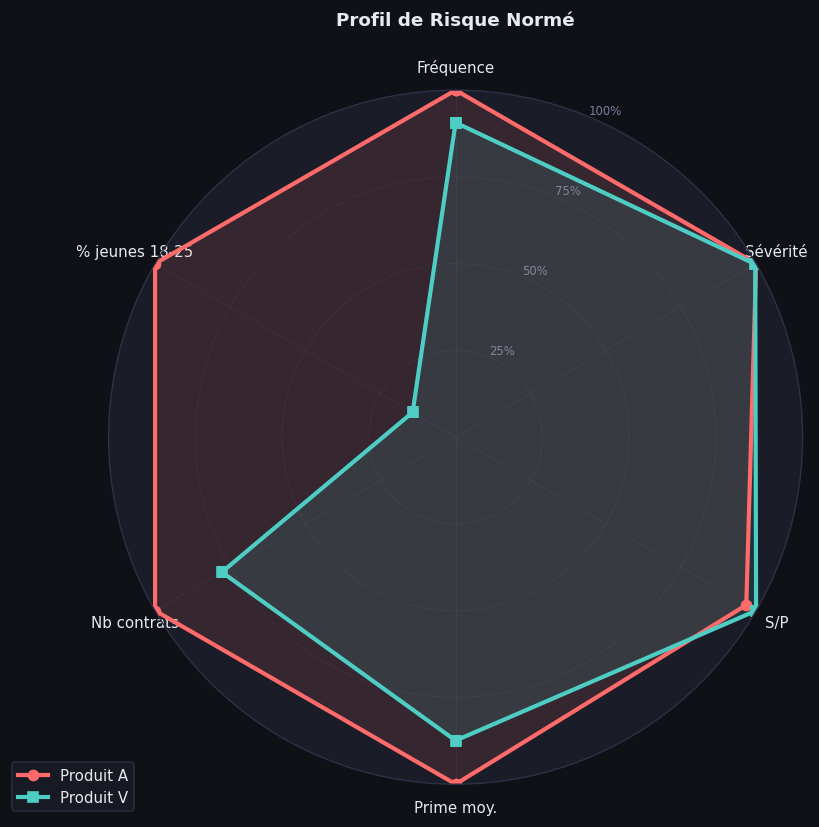

In [20]:
# ─── Radar chart ────────────────────────────────────────────────
categories = [
    "Fréquence", "Sévérité", "S/P",
    "Prime moy.", "Nb contrats", "% jeunes 18-25"
]
N = len(categories)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

raw_a = [
    kpi_A["frequence"], kpi_A["severite"],   kpi_A["sp_ratio"],
    kpi_A["prime_moy"], kpi_A["nb_contrats"],
    (df_A["age_tranche_h"] == "18-25").mean()
]
raw_v = [
    kpi_V["frequence"], kpi_V["severite"],   kpi_V["sp_ratio"],
    kpi_V["prime_moy"], kpi_V["nb_contrats"],
    (df_V["age_tranche_h"] == "18-25").mean()
]

def normalize_pair(a, v):
    mx = max(a, v)
    return (a / mx if mx else 0, v / mx if mx else 0)

pairs = [normalize_pair(a, v) for a, v in zip(raw_a, raw_v)]
vals_a = [p[0] for p in pairs] + [pairs[0][0]]
vals_v = [p[1] for p in pairs] + [pairs[0][1]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)
ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, size=9, color=TEXT)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], color=MUTED, size=7)
ax.set_ylim(0, 1)
ax.grid(color=GRID, linewidth=0.5)
ax.spines["polar"].set_edgecolor(BORDER)

ax.plot(angles, vals_a, "o-", color=A_MAIN, lw=2.5, ms=6, label="Produit A")
ax.fill(angles, vals_a, alpha=0.12, color=A_MAIN)
ax.plot(angles, vals_v, "s-", color=V_MAIN, lw=2.5, ms=6, label="Produit V")
ax.fill(angles, vals_v, alpha=0.12, color=V_MAIN)

ax.legend(loc="lower left", fontsize=9, bbox_to_anchor=(-0.15, -0.05))
ax.set_title("Profil de Risque Normé", color=TEXT, fontsize=11,
             fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


### 10.2 Lollipop — S/P par Garantie

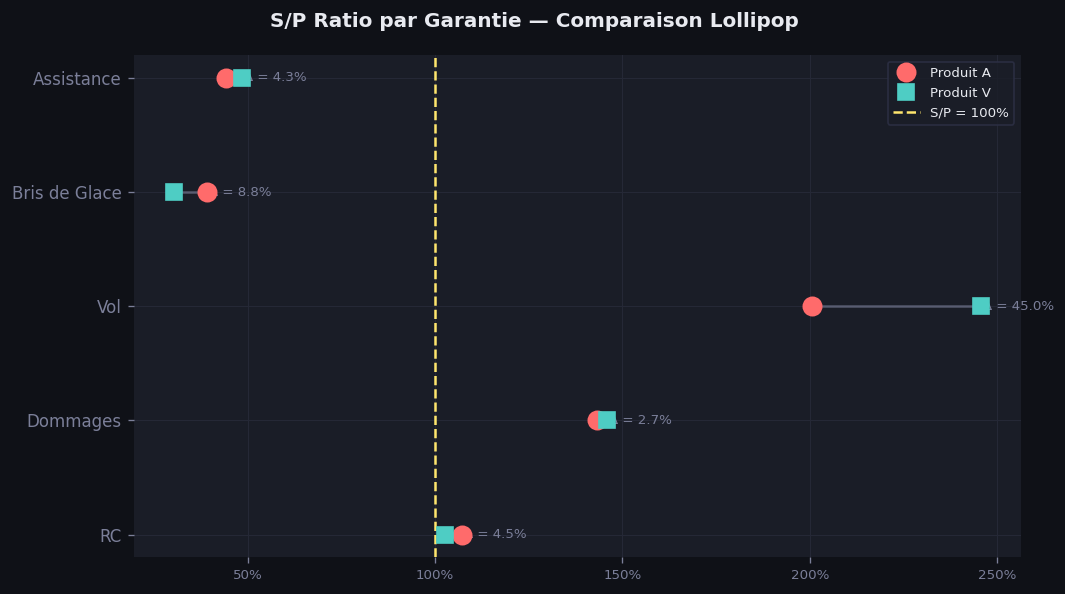

In [21]:
gars_common = [g for g in GAR_ORDER
               if g in kpi_gar_A.index and g in kpi_gar_V.index]

sp_a = [kpi_gar_A.loc[g, "sp_ratio"] for g in gars_common]
sp_v = [kpi_gar_V.loc[g, "sp_ratio"] for g in gars_common]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("S/P Ratio par Garantie — Comparaison Lollipop",
             fontsize=12, fontweight="bold")

for i, (va, vv, g) in enumerate(zip(sp_a, sp_v, gars_common)):
    ax.hlines(i, min(va, vv), max(va, vv), color=MUTED, lw=1.5, alpha=0.6)
    ax.plot(va, i, "o", color=A_MAIN, ms=11, zorder=5, label="Produit A" if i == 0 else "")
    ax.plot(vv, i, "s", color=V_MAIN, ms=10, zorder=5, label="Produit V" if i == 0 else "")
    ax.text(max(va, vv) + 0.005, i, f"Δ = {abs(va - vv):.1%}",
            va="center", fontsize=8, color=MUTED)

ax.axvline(1.0, color=ACCENT, linestyle="--", lw=1.5, label="S/P = 100%")
ax.set_yticks(range(len(gars_common)))
ax.set_yticklabels(gars_common, fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 10.3 Table de Synthèse Finale

In [22]:
# ─── Tableau comparatif final ────────────────────────────────────
summary = pd.DataFrame({
    "Produit A": {
        "Nb contrats":    kpi_A["nb_contrats"],
        "Prime totale (€)": kpi_A["prime_totale"],
        "Prime moyenne (€)": kpi_A["prime_moy"],
        "Nb sinistres":   kpi_A["nb_sinistres"],
        "Fréquence":      kpi_A["frequence"],
        "Sévérité (€)":   kpi_A["severite"],
        "S/P Ratio":      kpi_A["sp_ratio"],
    },
    "Produit V": {
        "Nb contrats":    kpi_V["nb_contrats"],
        "Prime totale (€)": kpi_V["prime_totale"],
        "Prime moyenne (€)": kpi_V["prime_moy"],
        "Nb sinistres":   kpi_V["nb_sinistres"],
        "Fréquence":      kpi_V["frequence"],
        "Sévérité (€)":   kpi_V["severite"],
        "S/P Ratio":      kpi_V["sp_ratio"],
    }
})
summary["Δ (V − A)"] = summary["Produit V"] - summary["Produit A"]
summary["Δ relatif"] = (summary["Produit V"] - summary["Produit A"]) / summary["Produit A"]

fmt_map = {
    "Nb contrats":       "{:,.0f}",
    "Prime totale (€)":  "{:,.0f}",
    "Prime moyenne (€)": "{:.1f}",
    "Nb sinistres":      "{:,.0f}",
    "Fréquence":         "{:.4f}",
    "Sévérité (€)":      "{:,.0f}",
    "S/P Ratio":         "{:.2%}",
}

(summary
 .style
 .format({c: fmt_map.get(c, "{:.4f}") for c in summary.columns[:3]})
 .format("{:+,.4f}", subset=["Δ (V − A)"])
 .format("{:+.2%}", subset=["Δ relatif"])
 .background_gradient(subset=["Δ relatif"], cmap="RdYlGn", vmin=-0.15, vmax=0.15)
 .set_caption("Synthèse Comparative — Produit A vs Produit V"))


,Produit A,Produit V,Δ (V − A),Δ relatif
Nb contrats,18000.0000,14000.0000,"-4,000.0000",-22.22%
Prime totale (€),4747255.7000,3228509.1900,"-1,518,746.5100",-31.99%
Prime moyenne (€),263.7364,230.6078,-33.1286,-12.56%
Nb sinistres,1567.0000,1105.0000,-462.0000,-29.48%
Fréquence,0.0871,0.0789,-0.0081,-9.34%
Sévérité (€),3911.0902,3899.1976,-11.8926,-0.30%
S/P Ratio,1.2910,1.3346,+0.0436,+3.37%


---

## Conclusions

| Dimension | Produit A | Produit V | Commentaire |
|---|---|---|---|
| **Volume** | 18 000 contrats | 14 000 contrats | A est plus grand de ~29% |
| **Prime moy.** | ~264 € | ~231 € | V tarifie légèrement moins cher |
| **Fréquence** | ~8,7% | ~7,9% | A a une sinistralité fréquence plus élevée |
| **Sévérité** | ~3 911 € | ~3 899 € | Niveaux quasi-identiques |
| **S/P** | ~129% | ~133% | Les deux produits sont techniquement déficitaires |
| **Jeunes (18-25)** | Fréquence ++, S/P dégradé | Identique | Effet âge présent sur les deux |
| **Electrique/Hybride** | Prime réduite (−8/12%) | Prime réduite (−15%) | V applique une remise plus forte |
| **Usage Pro** | Fréquence la plus haute | Identique | Cohérent avec l'exposition |

> **Note :** Les datasets sont synthétiques. Les calibrations de fréquence et sévérité  
> sont volontairement déficitaires (S/P > 100%) pour rendre l'analyse plus instructive.
